In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from river import tree, metrics
import pickle
import mlflow

cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f"Loaded dataset: {df.shape}")
print(f"Engines: {df['unit'].nunique()}")

Loaded dataset: (20631, 26)
Engines: 100


In [2]:
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [c for c in sensor_cols if df[c].std() == 0]
df.drop(columns=constant_sensors, inplace=True)
active_sensors = [c for c in df.columns if c.startswith('s')]
print(f"Dropped {len(constant_sensors)} constant sensors.")
print(f"Active sensors: {len(active_sensors)}")

all_units = sorted(df['unit'].unique())
np.random.seed(42)
np.random.shuffle(all_units)
train_df = df[df['unit'].isin(all_units[:70])].copy().reset_index(drop=True)
test_df  = df[df['unit'].isin(all_units[70:])].copy().reset_index(drop=True)
print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")

Dropped 4 constant sensors.
Active sensors: 17
Train: (14316, 23)  |  Test: (6315, 23)


In [3]:
drifted_datasets = {}

for level_name, noise_rate in [("Low", 0.001), ("High", 0.010)]:
    np.random.seed(42)
    drifted = test_df.copy()
    for col in active_sensors:
        s = train_df[col].std()
        noise = np.random.normal(0, noise_rate * (test_df['cycle'] ** 1.5) * s, len(test_df))
        drifted[col] = test_df[col] + noise
    drifted_datasets[level_name] = drifted
    print(f"{level_name} drift applied (rate = {noise_rate})")

Low drift applied (rate = 0.001)
High drift applied (rate = 0.01)


In [4]:
X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values

static_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
static_model.fit(X_train, y_train)

X_clean = test_df[active_sensors].values
y_clean = test_df['RUL'].values
static_preds_clean = static_model.predict(X_clean)
static_rmse_clean = np.sqrt(mean_squared_error(y_clean, static_preds_clean))
print(f"Static RF on clean test: RMSE = {static_rmse_clean:.2f}")

with open('../outputs/static_model.pkl', 'wb') as f:
    pickle.dump(static_model, f)

Static RF on clean test: RMSE = 44.00


In [5]:
static_results = {}

for level_name, drifted in drifted_datasets.items():
    X_test = drifted[active_sensors].values
    y_test = drifted['RUL'].values
    preds = static_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    static_results[level_name] = {"rmse": rmse}
    print(f"Static RF | {level_name} drift | RMSE = {rmse:.2f}")

Static RF | Low drift | RMSE = 56.81
Static RF | High drift | RMSE = 82.04


In [6]:
sgd_results = {}

for level_name, drifted in drifted_datasets.items():
    X_test = drifted[active_sensors].values
    y_test = drifted['RUL'].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    sgd = SGDRegressor(max_iter=1, tol=None, learning_rate='constant',
                       eta0=0.001, random_state=42)

    for _ in range(10):
        sgd.partial_fit(X_train_s, y_train)

    preds = sgd.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    sgd_results[level_name] = {"rmse": rmse}
    print(f"SGD Regressor | {level_name} drift | RMSE = {rmse:.2f}")

SGD Regressor | Low drift | RMSE = 56.53
SGD Regressor | High drift | RMSE = 346.90


In [7]:
inc_results = {}
per_bin_data = {}

for level_name, drifted in drifted_datasets.items():
    inc_model = tree.HoeffdingTreeRegressor(
        grace_period=50, delta=0.01,
        leaf_prediction='mean', max_depth=6
    )

    train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    for idx, row in train_shuffled.iterrows():
        inc_model.learn_one(row[active_sensors].to_dict(), row['RUL'])

    test_sorted = drifted.sort_values(['unit', 'cycle']).reset_index(drop=True)
    inc_metric = metrics.RMSE()
    inc_preds = []

    for idx, row in test_sorted.iterrows():
        x = row[active_sensors].to_dict()
        y = row['RUL']
        pred = inc_model.predict_one(x)
        if pred is not None:
            inc_metric.update(y, pred)
            inc_preds.append(pred)
        inc_model.learn_one(x, y)

    rmse = inc_metric.get()
    inc_results[level_name] = {"rmse": rmse}

    test_sorted['inc_pred'] = inc_preds
    test_sorted['inc_err_sq'] = (test_sorted['inc_pred'] - test_sorted['RUL']) ** 2
    test_sorted['static_pred'] = static_model.predict(drifted[active_sensors].values)
    test_sorted['static_err_sq'] = (test_sorted['static_pred'] - test_sorted['RUL']) ** 2
    per_bin_data[level_name] = test_sorted

    print(f"Hoeffding Tree | {level_name} drift | RMSE = {rmse:.2f}")

Hoeffding Tree | Low drift | RMSE = 56.99
Hoeffding Tree | High drift | RMSE = 66.65


In [8]:
print("\n" + "=" * 78)
print("SUMMARY: RMSE on Drifted Test Data")
print("=" * 78)
print(f"{'Drift':<8} {'Static RF':<12} {'SGD Incr.':<12} {'Hoeffding':<12} {'Best Incr. Impr.':<15}")
print("-" * 78)
for level in ["Low", "High"]:
    s  = static_results[level]['rmse']
    sg = sgd_results[level]['rmse']
    h  = inc_results[level]['rmse']
    best_incr = min(sg, h)
    imp = (s - best_incr) / s * 100
    print(f"{level:<8} {s:<12.2f} {sg:<12.2f} {h:<12.2f} {imp:<15.1f}")
print("=" * 78)


SUMMARY: RMSE on Drifted Test Data
Drift    Static RF    SGD Incr.    Hoeffding    Best Incr. Impr.
------------------------------------------------------------------------------
Low      56.81        56.53        56.99        0.5            
High     82.04        346.90       66.65        18.8           


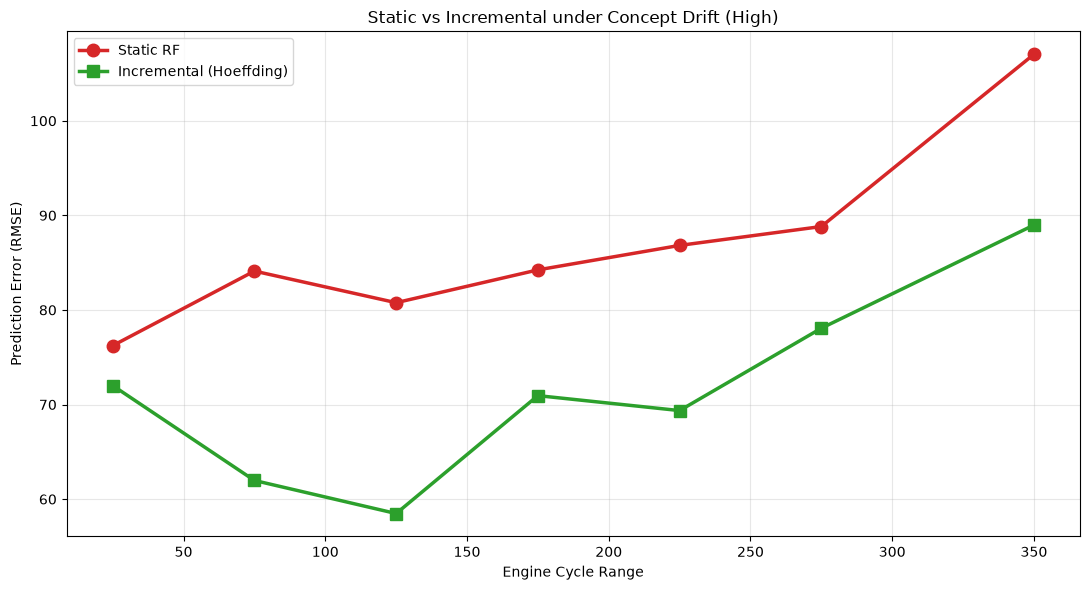

In [9]:
bins = [0, 50, 100, 150, 200, 250, 300, 400]
bin_midpoints = [25, 75, 125, 175, 225, 275, 350]

high_df = per_bin_data["High"].copy()
high_df['cycle_bin'] = pd.cut(high_df['cycle'], bins=bins)
static_per_bin = high_df.groupby('cycle_bin', observed=True)['static_err_sq'].mean().apply(np.sqrt)
inc_per_bin    = high_df.groupby('cycle_bin', observed=True)['inc_err_sq'].mean().apply(np.sqrt)

n = min(len(static_per_bin), len(inc_per_bin), len(bin_midpoints))
x  = bin_midpoints[:n]
sv = static_per_bin.values[:n]
iv = inc_per_bin.values[:n]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, sv, marker='o', linewidth=2.5, markersize=9, color='#d62728', label='Static RF')
ax.plot(x, iv, marker='s', linewidth=2.5, markersize=9, color='#2ca02c', label='Incremental (Hoeffding)')
ax.set_xlabel('Engine Cycle Range')
ax.set_ylabel('Prediction Error (RMSE)')
ax.set_title('Static vs Incremental under Concept Drift (High)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/hero_comparison.png', dpi=150)
plt.show()

In [10]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("continual_learning_industrial")

with mlflow.start_run(run_name="clean_final_run"):
    mlflow.log_param("train_engines", 70)
    mlflow.log_param("test_engines", 30)
    mlflow.log_param("active_sensors", len(active_sensors))

    for level in ["Low", "High"]:
        lvl = level.lower()
        mlflow.log_metric(f"static_rmse_{lvl}", static_results[level]['rmse'])
        mlflow.log_metric(f"sgd_rmse_{lvl}",    sgd_results[level]['rmse'])
        mlflow.log_metric(f"inc_rmse_{lvl}",    inc_results[level]['rmse'])

    mlflow.log_artifact("../outputs/hero_comparison.png")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

print("Done.")

Run ID: 7d4fd32c8c0a49519f74190a19a72673
Done.
